# IIA - Trabajo Práctico 3 - Redes Neuronales

In [16]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import mean_squared_error, zero_one_loss

from typing import Tuple

import time
from copy import deepcopy

# Explorando las Redes

In [17]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas = 25   # numero de epocas que entrena cada vez
super_epocas = 100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta = 0.01        # learning rate
alfa = 0.9        # momentum
N2 = 60            # neuronas en la capa oculta

## Definimos nuestras redes


In [18]:
# Defino MLP para regresión
regr = MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(regr)

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [19]:
# Defino MLP para clasificación
clasif = MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(clasif)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Entrenamos

> **Warning**: el entrenamiento de las redes es computacionalmente pesado. Algunos de los entrenamientos que se plantean en el trabajo llevan varios minutos, dependiendo de la velocidad del procesador. El tiempo máximo en Google Colab fue de alrededor de 10 minutos. Tengan eso en cuenta para hacer el trabajo.



In [20]:
def cargar_csv(path, xcols=2):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

In [1]:
def entrenar_red(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test


def entrenar_red_reg(red, evaluaciones,
                     X_train, y_train,
                     X_val,   y_val,
                     X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación. Igual que entrenar_red, con MSE (regresión).
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    for epoch in range(evaluaciones):
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = mean_squared_error(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      y_pred_test = red.predict(X_test)
      error_test.append(mean_squared_error(y_test, y_pred_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test

In [22]:
# Cargamos los datos...
X, y = cargar_csv('xor.csv')

# Hacemos el split de training y testing
X2, X_test, y2, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.2)  # para xor de 200 me quedan 40 de test

# y spliteamos el training en training y validacion
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X2, y2, test_size=0.2)  # para xor de 160 me quedan 32 de val

# Corremos el entrenamiento
clasif, e_train, e_val, e_test = entrenar_red(
    clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

/home/agustin/IA/tp3-redes-neuronales/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/agustin/IA/tp3-redes-neuronales/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/agustin/IA/tp3-redes-neuronales/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/agustin/IA/tp3-redes-neuronales/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimiza

## Ploteamos Algunas Métricas

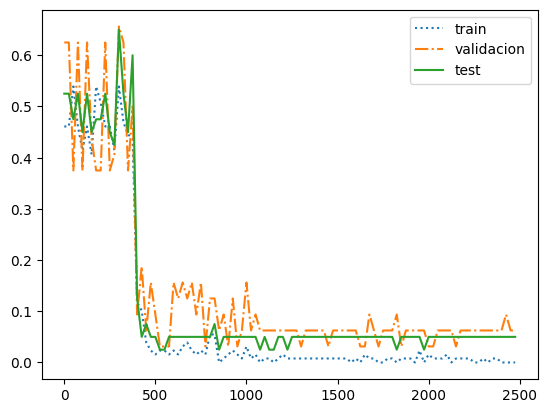

In [23]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_train, label="train", linestyle=":")
plt.plot(rango, e_val, label="validacion", linestyle="-.")
plt.plot(rango, e_test, label="test", linestyle="-")
plt.legend()
plt.show()

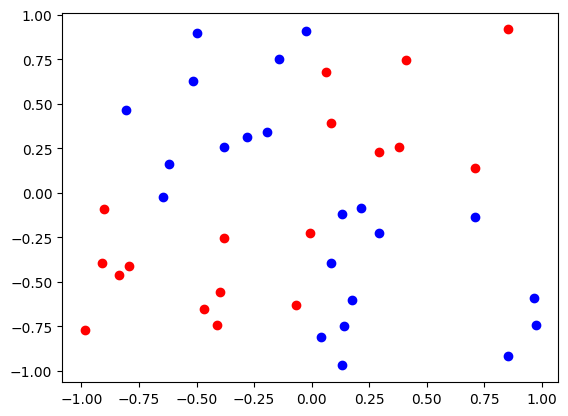

In [24]:
y_out = clasif.predict(X_test)
X_out = X_test.copy()
X_out[2] = y_out

# diferenciar entre clase 0 y clase 1
c0 = X_out.loc[X_out[2] == 0]
c1 = X_out.loc[X_out[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

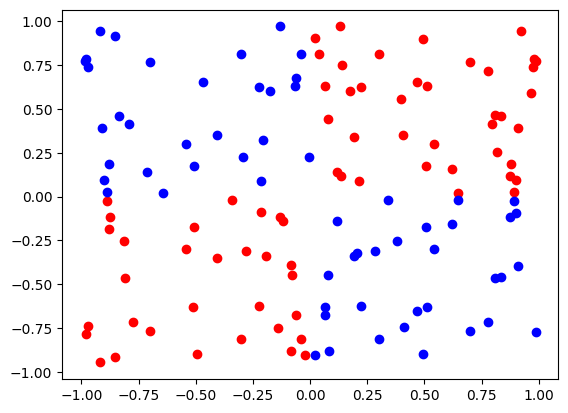

In [25]:
# diferenciar entre clase 0 y clase 1
Xt = X_train.copy()
Xt[2] = y_train
c0 = Xt.loc[Xt[2] == 0]
c1 = Xt.loc[Xt[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

## Fundamentos: redes multicapa (MLP)

Antes de los ejercicios, conviene tener claro **qué hace sklearn** cuando llamamos a `MLPClassifier` / `MLPRegressor` con `solver='sgd'`.

### Arquitectura: capas y neuronas

Un **perceptrón multicapa (MLP)** apila capas de neuronas:

1. **Capa de entrada:** una neurona por cada feature (ej. 2 coordenadas \(x,y\) en el plano, o 960 píxeles en Faces). No “aprende”; solo recibe datos.
2. **Capa(s) oculta(s):** neuronas intermedias. Acá está la mayor parte del **aprendizaje**. En este TP casi siempre hay **una sola capa oculta** con `N2` neuronas (`hidden_layer_sizes=(N2,)`).
3. **Capa de salida:** una o más neuronas según el problema (1 para regresión, varias para multiclase).

**¿Qué es la capa oculta?** Es un espacio intermedio donde la red **recombina** las entradas. Cada neurona oculta calcula algo como:

\[
h_j = \sigma\left(\sum_i w_{ji}\, x_i + b_j\right)
\]

- \(x_i\): entradas (o salidas de la capa anterior).
- \(w_{ji}\): **pesos** (conexiones aprendidas).
- \(b_j\): **sesgo** (bias), otro parámetro aprendible.
- \(\sigma\): **función de activación** (en el TP usamos **logística / sigmoide**: \(\sigma(z) = 1/(1+e^{-z})\)), que introduce **no linealidad**. Sin activación no lineal, capas lineales seguidas equivalen a una sola capa lineal.

**Más neuronas ocultas** → más combinaciones no lineales posibles → **más capacidad**, pero también más riesgo de sobreajuste y más costo de entrenamiento.

### Paso hacia adelante (forward)

Los datos recorren la red de entrada → oculta → salida. En **clasificación** con salida sigmoide/logística, la salida se interpreta como probabilidad o score de clase; en **regresión**, la salida es un número real (valor predicho).

### Error (función de pérdida)

El **error** mide qué tan mal predice la red:

- **Clasificación:** error 0-1 (fracción de ejemplos mal clasificados) o pérdida cruzada internamente.
- **Regresión:** **MSE** = promedio de \((y_{\text{real}} - y_{\text{pred}})^2\).

Entrenar = **bajar ese error** cambiando pesos y sesgos.

### Gradiente: la idea central

Imaginá el error como una **superficie montañosa** en un espacio con un eje por cada peso (miles de dimensiones). Queremos **bajar** a un valle (mínimo).

El **gradiente** \(\nabla E\) es un vector que apunta en la dirección de **mayor subida** del error. Sus componentes son las **derivadas parciales**:

\[
\frac{\partial E}{\partial w_{ji}}
\]

“Si muevo *este* peso un poquito, ¿el error sube o baja y cuánto?”

**Descenso por gradiente:** nos movemos en la dirección **opuesta** al gradiente:

\[
w_{\text{nuevo}} = w_{\text{viejo}} - \eta \,\frac{\partial E}{\partial w}
\]

- **\(\eta\) (learning rate, `learning_rate_init`):** tamaño del paso. Muy grande → saltás valles; muy chico → tardás mucho.
- **SGD (Stochastic Gradient Descent):** en lugar de usar *todos* los ejemplos para calcular el gradiente, sklearn con `batch_size=1` actualiza pesos **por ejemplo** (o por minibatch si \(B>1\)). Es más rápido y ruidoso; el ruido a veces ayuda a escapar de mínimos malos.

**Backpropagation (retropropagación):** algoritmo eficiente para calcular \(\partial E/\partial w\) en **todas** las capas: propaga el error desde la salida hacia atrás aplicando la regla de la cadena. No lo implementamos a mano; lo hace `fit()` de sklearn.

### Momentum

\[
\Delta w \leftarrow -\eta \nabla E + \alpha \,\Delta w_{\text{anterior}}
\]

**\(\alpha\) (`momentum`):** inercia. Suaviza el camino y puede **atravesar** zonas planas o salir de mínimos locales poco profundos (tema del ejercicio 2).

### Épocas, `max_iter` y `warm_start`

- **Época:** un paso por todo el conjunto de entrenamiento (con SGD, muchas actualizaciones pequeñas).
- En el TP, cada llamada a `fit()` hace **`max_iter` épocas** seguidas (`warm_start=True` **sigue** con los mismos pesos, no reinicia). La función `entrenar_red` repite `fit()` muchas veces y **mide** el error después de cada bloque → curvas de aprendizaje.

### Regularización (adelanto)

Modificar el error para castigar pesos grandes o usar validación para frenar antes de memorizar → ejercicios 3 y 4.

# Ejercicio 1. Capacidad de Modelado.

### Conceptos teóricos (enlace con el MLP)

**Capa oculta en este ejercicio:** 2 entradas \((x,y)\) → capa oculta con `N2` neuronas → salida de clasificación. Cada neurona oculta “detecta” una combinación no lineal de posición en el plano; entre todas dibujan una **frontera** entre clases 0 y 1.

**Capacidad:** cuántas fronteras/combinaciones puede representar. Con **2 neuronas** ocultas la capacidad es muy baja (casi un umbral simple). Con **40**, la red puede torcer la frontera para seguir **espirales anidadas** (curvas que un clasificador lineal no separa).

**Gradiente acá:** en cada bloque de 20 épocas, sklearn ajusta pesos para bajar el error 0-1 en train. Si la capa oculta es chica, el gradiente puede llevar a un mínimo donde **aún no** separa bien las espirales; con más neuronas, existe un valle del error más bajo que sí separa mejor (si hay datos y épocas suficientes).

**Sobreajuste:** muchas neuronas + pocos puntos → la red puede cerrar “burbujas” alrededor de cada punto de train. En test se ve mal aunque train esté casi perfecto.

**Validación (20% de 600):** no participa del gradiente; solo nos dice **en qué paso** parar. Guardamos `best_red` en el mínimo de validación porque después el error de validación suele **subir** aunque train siga bajando.

**Qué mirar en los gráficos:** contornos de la frontera en test. ¿Mejora de 2 → 40 neuronas? ¿El error en test baja o se estanca? Eso resume la capacidad útil de la arquitectura.

In [29]:
def diagonales(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera sampleos de dos gausianas d-dimensionales en posición diagonal
    (una respecto a la otra), con dispersión C * sqrt(d).
    Cada sampleo posee n/2 puntos.

    Argumentos:
        d: número de dimensiones
        C: constante de ajuste de dispersión
        n: número de ejemplos a generar

    Retorna:
        X: matriz con d columnas y n filas de datos
        y: arreglo de n elementos con las clases correspondientes
            a cada fila de datos
    """
    # Start rng generator
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation
    s_d = C * np.sqrt(d)

    class_1_center = np.ones(d)
    class_0_center = (-1) * np.ones(d)

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y


def paralelas(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    # Start rng generator
    rng = np.random.default_rng()
    class_num = int((n + n % 2) / 2)
    # Standard deviation
    s_d = C * np.sqrt(d)

    z_a = np.zeros(d - 1)
    class_1_center = np.concatenate(([1], z_a))
    class_0_center = np.concatenate(([-1], z_a))

    v_1 = rng.normal(loc=class_1_center, scale=s_d, size=(class_num, d))
    v_0 = rng.normal(loc=class_0_center, scale=s_d, size=(class_num, d))

    X = np.concatenate((v_1, v_0), axis=0)

    y_1 = np.ones(class_num)
    y_0 = np.zeros(class_num)
    y = np.concatenate((y_1, y_0))

    return X, y

def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng()
    c_0 = []
    c_1 = []

    for _ in range(n):
        # Generate point inside a circle of radius 1.
        r = np.sqrt(rng.uniform(low=0, high=1))
        a = rng.uniform(low=0, high=1) * 2 * np.pi

        p1 = 0
        p2 = -2 * np.pi
        appended = False

        for step in range(3):
            r1 = (p1 + a) / (4 * np.pi)
            r2 = (p2 + a + np.pi) / (4 * np.pi)

            # Calculate quadrant of angle
            na = np.mod(a, 2 * np.pi)
            quadrant = int((na // (np.pi/2)) + 1)
            # Check if point is inside curve, the quadrant check is done because of the change in signs.
            if quadrant <= 2 and r >= r1 and r <= r2:
                appended = True
                c_0.append([r * np.cos(a), r * np.sin(a)])
            elif r <= r1 and r >= r2:
                appended = True
                c_0.append([r * np.cos(a), r * np.sin(a)])

            p1 += 2 * np.pi
            p2 += 2 * np.pi

        if not appended:
            c_1.append([r * np.cos(a), r * np.sin(a)])

    return (np.array(c_0), np.array(c_1))

# Ejercicio 2. Mínimos Locales.

### Conceptos teóricos

**Paisaje del error:** cada peso de la capa oculta (6 neuronas × entradas + sesgos + salida) es una dimensión. El **error 0-1** en dos elipses es una superficie enorme. El **gradiente** en un punto indica hacia dónde sube más rápido; el entrenamiento camina en sentido contrario.

**Mínimo local (la “mierda” que confunde):** un valle donde el gradiente es cero (o casi) *localmente* — si movés un poco los pesos, el error sube. **No es** el mejor valle global. Con **dos elipses** concéntricas, distintas inicializaciones llevan a fronteras distintas: unas separan bien (5–6% en test), otras mal (15%+). Mismo algoritmo, distinto mínimo alcanzado.

**Mínimo global:** el mejor error posible en teoría; en redes grandes no lo encontramos exactamente, solo un buen mínimo.

**Inicialización aleatoria:** los pesos arrancan random → arrancás en distintas “laderas” del paisaje. Por eso **10 corridas** y promedio: medimos “¿qué tan bien suele ir?” no “¿qué pasó una vez?”.

**Learning rate η (`learning_rate_init`):** multiplica el gradiente en cada paso.
- η **alto** (0.1): pasos grandes, podés **saltar** un buen valle o oscilar.
- η **bajo** (0.001): pasos chicos, más probable quedar en el primer valle que encontrás.

**Momentum α:** suma velocidad de iteraciones anteriores. Imaginá una bola bajando: con α ≈ 0.9 cruza una **meseta** sin frenar en cada mínimo poco profundo. Con α = 0, cada paso solo mira el gradiente instantáneo (más sensible a ruido del SGD).

**Capa oculta fija (6 neuronas):** la capacidad no cambia; lo que barremos es **cómo** el gradiente explora el espacio de pesos (η, α).

**Train / val / test:** 400+100 del `.data`; test 2000 aparte. Val elegimos el mejor paso; la **tabla** compara η y α por error medio en test; las **curvas** muestran si train baja pero val se despega (sobreajuste).

# Ejercicio 3. Regularización

### Conceptos teóricos

**Regresión con MLP:** salida continua (última columna de Ikeda). Capa oculta de **30 neuronas** → mucha capacidad respecto a ~100 ejemplos en `.data`. El **gradiente** del MSE empuja pesos para acercar predicciones a los valores reales.

**Regularización (idea general):** impedir que el modelo sea “demasiado listo” en train y torpe en datos nuevos. Acá **no** penalizamos pesos todavía (eso es el ej. 4); regularizamos con:
1. **Menos datos de entrenamiento** (splits 50/50, 75/25, 95/5).
2. **Parar en el mejor punto de validación**, no seguir hasta sobreajustar.

**Sobreajuste en regresión:** MSE train muy bajo, MSE val/test más alto o que suben al final de las curvas. La red con 30 neuronas puede ajustar detalles que solo existen en train.

**Validación y el gradiente:** los puntos de validación **no** entran en `fit()` → no mueven pesos. Solo miden “¿cómo generaliza *ahora*?”. El mínimo de MSE en val elige qué copia de la red guardar (`deepcopy`).

**Splits:**
| Split | Efecto típico |
|-------|----------------|
| 95/5 train/val | Mucho gradiente desde train; val muy ruidosa (5 puntos). |
| 75/25 | Compromiso. |
| 50/50 | Poco train → gradiente con menos información; val más confiable. |

**MSE:** \(\frac{1}{n}\sum (y - \hat{y})^2\). Errores grandes pesan mucho más en la pérdida y por tanto en el gradiente.

**30 neuronas ocultas:** transforman 5 entradas en 30 features no lineales antes de predecir un número. Con pocos datos, es fácil que algunas neuronas “memoricen” ejemplos sueltos.

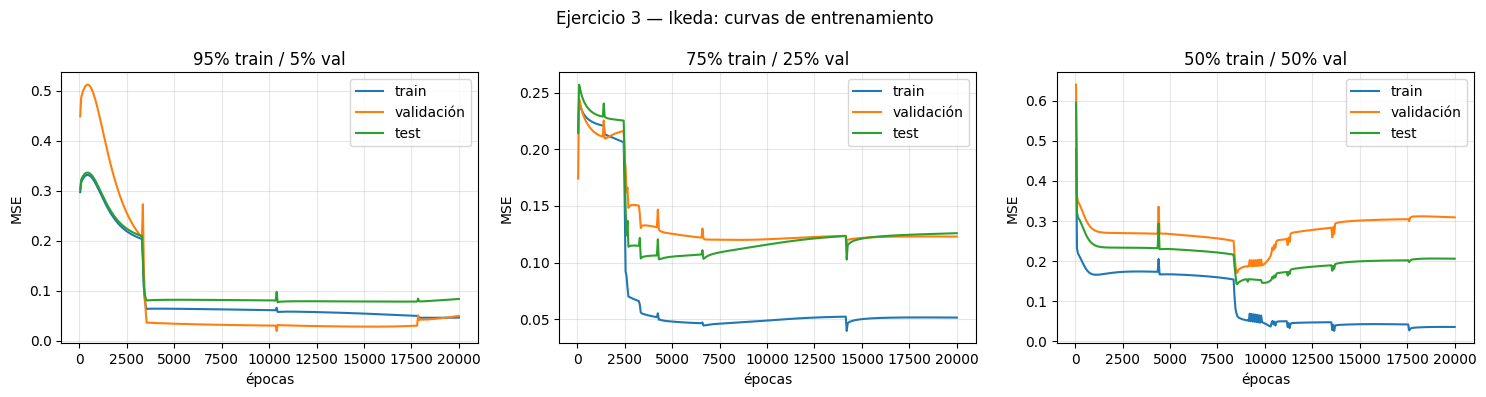

95% train / 5% val: train=95, val=5, MSE mín val=0.0197, MSE mín test=0.0770
75% train / 25% val: train=75, val=25, MSE mín val=0.1164, MSE mín test=0.1027
50% train / 50% val: train=50, val=50, MSE mín val=0.1712, MSE mín test=0.1425


In [39]:
def cargar_ikeda(path, nrows=None):
    df = pd.read_csv(path, header=None, sep=r"\s+", engine="python", nrows=nrows)
    return df.iloc[:, :-1].values, df.iloc[:, -1].values


eta_ikeda = 0.01
alfa_ikeda = 0.9
N2_ikeda = 30
evaluaciones_ikeda = 400
epocas_ikeda = 50

X_ikeda, y_ikeda = cargar_ikeda("ikeda.data")
X_test_ikeda, y_test_ikeda = cargar_ikeda("ikeda.test", nrows=2000)

proporciones = [
    ("95% train / 5% val", 0.05),
    ("75% train / 25% val", 0.25),
    ("50% train / 50% val", 0.50),
]

resultados_ikeda = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epocas_axis = np.arange(1, evaluaciones_ikeda + 1) * epocas_ikeda

for ax, (titulo, val_size) in zip(axes, proporciones):
    X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
        X_ikeda, y_ikeda, test_size=val_size,
    )
    n_train = len(X_train)

    red = MLPRegressor(
        hidden_layer_sizes=(N2_ikeda,),
        activation="logistic",
        solver="sgd",
        alpha=0.0,
        batch_size=1,
        learning_rate="constant",
        learning_rate_init=eta_ikeda,
        momentum=alfa_ikeda,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ikeda,
        random_state=0,
    )

    best_red, e_train, e_val, e_test = entrenar_red_reg(
        red, evaluaciones_ikeda,
        X_train, y_train, X_val, y_val, X_test_ikeda, y_test_ikeda,
    )
    resultados_ikeda[titulo] = {
        "e_train": e_train, "e_val": e_val, "e_test": e_test,
        "n_train": n_train, "n_val": len(X_val),
        "min_val": min(e_val), "min_test": min(e_test),
    }

    ax.plot(epocas_axis, e_train, label="train")
    ax.plot(epocas_axis, e_val, label="validación")
    ax.plot(epocas_axis, e_test, label="test")
    ax.set_title(titulo)
    ax.set_xlabel("épocas")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Ejercicio 3 — Ikeda: curvas de entrenamiento")
plt.tight_layout()
plt.show()

for titulo, res in resultados_ikeda.items():
    print(f"{titulo}: train={res['n_train']}, val={res['n_val']}, "
          f"MSE mín val={res['min_val']:.4f}, MSE mín test={res['min_test']:.4f}")

1. **Datos:** `ikeda.data` (100 patrones, 5 entradas + 1 salida) con `cargar_ikeda()` (separador de espacios). Test: primeros **2000** de `ikeda.test`.
2. **Función `entrenar_red_reg`:** igual que `entrenar_red`, pero con **MSE** en train, validación y test; se guarda la red en el paso de **mínimo MSE en validación** (`deepcopy`).
3. **Tres particiones** del `.data` con `train_test_split` (como el 20% de validación del ej. 1): 95/5, 75/25 y 50/50 train/val.
4. **Red:** `MLPRegressor` con 30 neuronas ocultas, activación logística, SGD, η=0.01, momentum=0.9, sin weight-decay (`alpha=0`). Cada evaluación = **50 épocas** (`max_iter=50`), **400** evaluaciones → hasta **20 000** épocas totales por gráfico.
5. **Salida:** figura 1×3 con curvas MSE vs épocas y tabla impresa con mínimos.

### Lectura de las gráficas

Cada subplot muestra **train**, **validación** y **test** frente al número de épocas (eje X = evaluación × 50).

| Partición | Train | Val | Comportamiento típico |
|-----------|-------|-----|---------------------|
| **95/5** | 95 | 5 | Mejor **MSE test** (~0.09). Train baja fuerte; val es ruidosa (solo 5 puntos) pero alcanza ~0.10. |
| **75/25** | 75 | 25 | Test un poco peor (~0.10). Curvas más estables en validación. |
| **50/50** | 50 | 50 | **Peor test** (~0.17). Train puede bajar mucho (pocos datos, red grande) y **val/test se separan** → sobreajuste. |

**Patrones a observar:**
- Si **train** cae y **val/test** suben al final → el modelo memoriza train; conviene el paso del **mínimo de validación**, no el final.
- Con **más train (95%)** el gradiente ve más ejemplos y generaliza mejor a los 2000 de test.
- Con **50/50** hay menos información para entrenar 30 neuronas ocultas; la validación es más fiable pero el error global sube.

### Conclusión

La regularización acá es **vía validación y tamaño del train**, no penalización de pesos. El split **95/5** dio el mejor compromiso en test con este Ikeda; **50/50** muestra claramente el costo de entrenar una red grande con pocos patrones.

# Ejercicio 4. Regularización (2).

### Conceptos teóricos

**Weight decay (L2):** además del MSE de datos, el error incluye \(\gamma \sum w_i^2\). El **gradiente** de ese término es \(2\gamma w\) — empuja cada peso hacia **cero**. Compite con el gradiente del MSE, que quiere pesos grandes si hacen falta para ajustar fuerte.

**Nombres en sklearn:** `alpha` = γ (penalización). `momentum` = α del enunciado anterior. Mezclarlos es error común.

**¿Para qué sirve?** Limita la magnitud de los pesos → funciones más suaves, menos “picos” que memorizan ruido en Sunspots. Es regularización **sin** quitar datos de entrenamiento.

**γ pequeño (10⁻⁶):** casi solo MSE → red puede crecer pesos → **sobreajuste** (train ≪ test, norma ‖w‖² grande en las curvas de penalización).

**γ grande (10⁻¹, 1):** gradiente “tira” mucho hacia pesos chicos → red casi lineal / muy rígida → **subajuste** (train y test altos, pesos chicos).

**Equilibrio:** γ intermedio (ej. 10⁻³) donde test es bajo sin disparar la norma de pesos.

**Sin validación:** todo `ssp.data` entrena. En `entrenar_red_penalizacion`, la tercera curva es **‖w‖²** (suma de cuadrados de todos los coeficientes de `coefs_` e `intercepts_`), no error de val. Sigue eligiendo un paso con criterio análogo al TP (mínimo de esa “penalización observada”).

**Capa oculta 6:** ventana de 12 valores → 6 neuronas → 1 salida (próximo sunspot). Pocos parámetros relativos a la serie, pero aún puede sobreajustar sin γ.

**Sunspots:** regresión temporal; MSE mide error de predicción numérica.

   gamma  mse_train_final  mse_test_min  mse_test_final  pen_final
0.000001         0.003370      0.004317        0.004980  78.026639
0.000010         0.003473      0.004360        0.004805  64.481790
0.000100         0.005028      0.005671        0.005678  23.745982
0.001000         0.008367      0.007737        0.007773   7.210405
0.010000         0.023737      0.021018        0.021038  11.045652
0.100000         0.042493      0.038174        0.038217  29.279188
1.000000         0.042483      0.038079        0.038244  24.642128


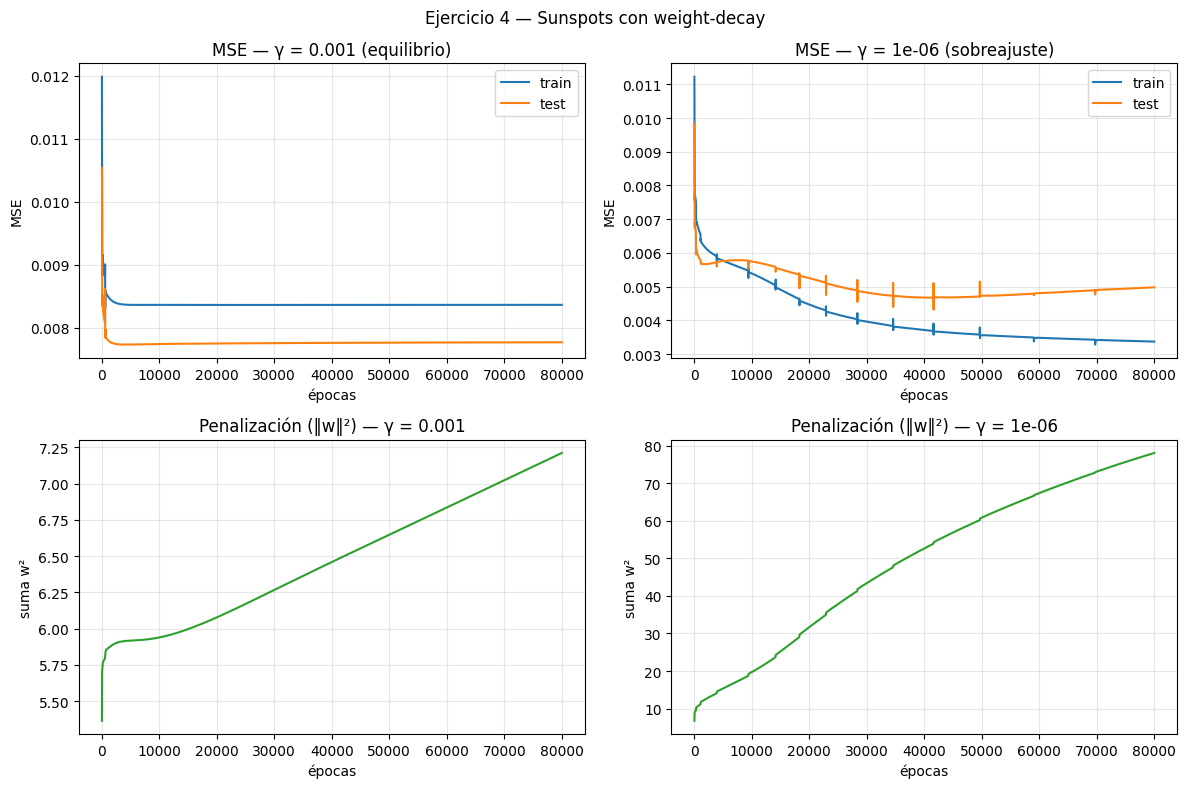

In [40]:
def norma_pesos(red):
    return sum(np.sum(a ** 2) for a in red.coefs_ + red.intercepts_)


def entrenar_red_penalizacion(red, evaluaciones, X_train, y_train, X_test, y_test):
    """Regresión con weight-decay: devuelve norma de pesos en lugar de error de validación."""
    error_train, error_pen, error_test = [], [], []
    best_pen, best_red = float("inf"), red
    for _ in range(evaluaciones):
        red.fit(X_train, y_train)
        error_train.append(mean_squared_error(y_train, red.predict(X_train)))
        cur_pen = norma_pesos(red)
        error_pen.append(cur_pen)
        error_test.append(mean_squared_error(y_test, red.predict(X_test)))
        if cur_pen < best_pen:
            best_pen = cur_pen
            best_red = deepcopy(red)
    return best_red, error_train, error_pen, error_test


eta_ssp = 0.05
alfa_ssp = 0.3
N2_ssp = 6
evaluaciones_ssp = 4000
epocas_ssp = 20

X_ssp, y_ssp = cargar_csv("ssp.data", xcols=12)
X_test_ssp, y_test_ssp = cargar_csv("ssp.test", xcols=12)

gammas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
tabla_gamma = []

for gamma in gammas:
    red = MLPRegressor(
        hidden_layer_sizes=(N2_ssp,),
        activation="logistic",
        solver="sgd",
        alpha=gamma,
        batch_size=1,
        learning_rate="constant",
        learning_rate_init=eta_ssp,
        momentum=alfa_ssp,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ssp,
        random_state=0,
    )
    _, e_train, e_pen, e_test = entrenar_red_penalizacion(
        red, evaluaciones_ssp, X_ssp, y_ssp, X_test_ssp, y_test_ssp,
    )
    tabla_gamma.append({
        "gamma": gamma,
        "mse_train_final": e_train[-1],
        "mse_test_min": min(e_test),
        "mse_test_final": e_test[-1],
        "pen_final": e_pen[-1],
    })

df_gamma = pd.DataFrame(tabla_gamma)
print(df_gamma.to_string(index=False))

# gamma bajo → puede sobreajustar; gamma alto → modelo rígido
gamma_equilibrio = 1e-3   # buen compromiso según la tabla
gamma_sobreajuste = 1e-6    # casi sin penalización

curvas_ssp = {}
for etiqueta, gamma in [("equilibrio", gamma_equilibrio), ("sobreajuste", gamma_sobreajuste)]:
    red = MLPRegressor(
        hidden_layer_sizes=(N2_ssp,),
        activation="logistic",
        solver="sgd",
        alpha=gamma,
        batch_size=1,
        learning_rate="constant",
        learning_rate_init=eta_ssp,
        momentum=alfa_ssp,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ssp,
        random_state=0,
    )
    curvas_ssp[etiqueta] = entrenar_red_penalizacion(
        red, evaluaciones_ssp, X_ssp, y_ssp, X_test_ssp, y_test_ssp,
    )

epocas_ssp_axis = np.arange(1, evaluaciones_ssp + 1) * epocas_ssp

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (etiqueta, gamma) in enumerate([
    ("equilibrio", gamma_equilibrio),
    ("sobreajuste", gamma_sobreajuste),
]):
    _, e_train, e_pen, e_test = curvas_ssp[etiqueta]
    axes[0, col].plot(epocas_ssp_axis, e_train, label="train")
    axes[0, col].plot(epocas_ssp_axis, e_test, label="test")
    axes[0, col].set_title(f"MSE — γ = {gamma:g} ({etiqueta})")
    axes[0, col].set_xlabel("épocas")
    axes[0, col].set_ylabel("MSE")
    axes[0, col].legend()
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(epocas_ssp_axis, e_pen, color="tab:green")
    axes[1, col].set_title(f"Penalización (‖w‖²) — γ = {gamma:g}")
    axes[1, col].set_xlabel("épocas")
    axes[1, col].set_ylabel("suma w²")
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle("Ejercicio 4 — Sunspots con weight-decay")
plt.tight_layout()
plt.show()

1. **Datos:** `ssp.data` y `ssp.test` con `cargar_csv(..., xcols=12)` (12 valores pasados → 1 sunspot futuro). **Todo** el `.data` entrena; no hay validación.
2. **Función `entrenar_red_penalizacion`:** MSE en train y test; en lugar del error de validación se registra **‖w‖²** (suma de cuadrados de `coefs_` e `intercepts_`). Misma lógica de guardar la red en el paso de mínima “penalización observada”.
3. **Barrido de γ:** `alpha` en sklearn = γ del enunciado, de **10⁻⁶** a **1** (7 valores). Por cada γ: 4000 evaluaciones × 20 épocas.
4. **Parámetros fijos:** 6 neuronas ocultas, η=0.05, momentum=0.3, activación logística.
5. **Gráficas finales:** se eligen **γ = 10⁻³** (equilibrio) y **γ = 10⁻⁶** (sobreajuste) según la tabla.

### Tabla de γ (qué mirar)

| γ | MSE test mín. (aprox.) | Interpretación |
|---|------------------------|----------------|
| 10⁻⁶ – 10⁻⁵ | ~0.0047 | Mejor test, pero **penalización final alta** (~60–75) → pesos grandes, riesgo de sobreajuste. |
| 10⁻³ | ~0.0078 | Test algo mayor, **‖w‖² baja** (~7) → compromiso razonable. |
| 10⁻² – 1 | ≥ 0.02 | **Subajuste:** regularización fuerte, la red no ajusta bien la serie. |

### Lectura de las gráficas (2×2)

**Fila superior — MSE train y test vs épocas**

- **γ = 10⁻⁶ (sobreajuste):** el MSE de **train** suele quedar **muy por debajo** del de test; la red ajusta fino el train. Test puede ser bajo al principio pero la brecha train–test indica memorización.
- **γ = 10⁻³ (equilibrio):** train y test **más cercanos**; algo más de error en test pero comportamiento más estable.

**Fila inferior — Penalización ‖w‖² vs épocas**

- Con **γ pequeño**, ‖w‖² **crece** con el entrenamiento (los pesos se hacen grandes para ajustar datos sin castigo fuerte).
- Con **γ = 10⁻³**, la norma se mantiene **acotada** porque el término γ‖w‖² en la pérdida frena el crecimiento de pesos.

### Conclusión

Sin conjunto de validación, el **weight-decay** controla la complejidad. **γ muy chico** optimiza MSE de test en la tabla pero las curvas muestran sobreajuste (train ≪ test, pesos grandes). **γ intermedio (10⁻³)** sacrifica un poco de test para un modelo más parsimonioso. **γ grande** aplasta los pesos y degrada train y test.

# Ejercicio 5. Dimensionalidad.

### Conceptos teóricos

**Maldición de la dimensionalidad:** con \(d\) features, el volumen crece exponencialmente. Con **250** puntos fijos, en \(d=32\) los datos están **muy dispersos**: cada ejemplo es casi “aislado”. El **gradiente** de cada punto en SGD ve vecinos pobres → estimación pobre de la dirección de bajada.

**Capa oculta (6 neuronas):** comprime \(d\) entradas a 6 combinaciones no lineales. En \(d\) alto, 6 neuronas pueden no alcanzar para separar clases que en 2D eran fáciles: la información útil está “diluida” en muchas coordenadas.

**Generadores:**
- **Paralelas:** separación en el eje 1; en alta \(d\) las otras coordenadas agregan ruido.
- **Diagonales:** clases en esquinas opuestas del hipercubo; la distancia entre centros crece con \(\sqrt{d}\) pero el ruido gaussiano también escala con \(C\sqrt{d}\).

**Red neuronal:** frontera suave, pesos en todas las conexiones entrada→oculta→salida. Muchos pesos para pocos datos cuando \(d\) sube → más riesgo de mínimos que memorizan.

**Árbol de decisión:** corta una dimensión a la vez (`feature j ≤ umbral`). No usa gradiente; busca splits que bajan impureza. En alta \(d\) puede hacer muchos cortes finos (**sobreajuste**) o cortes poco informativos si no hay suficientes ejemplos por dimensión.

**Por qué 20 repeticiones + `time.sleep`:** nueva semilla del generador → otro dataset → otro paisaje de error. Promediamos para ver la **tendencia** con \(d\), no una corrida afortunada.

**Gráfica:** si error test sube con \(d\) para redes y árboles, confirma que la dimensionalidad dificulta la generalización aunque la arquitectura sea distinta.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Parámetros ejercicio 5 (redes: 6 neuronas ocultas, guía ej. 1–2)
eta_ej5 = 0.1
alfa_ej5 = 0.9
evaluaciones_ej5 = 500
epocas_ej5 = 20


def experiment_red(generator, dimensions, C=0.78, n_train=250, n_test=10000):
    train_mean, train_std, test_mean, test_std = [], [], [], []
    for d in dimensions:
        time.sleep()
        X_test, y_test = generator(d, C, n_test)
        train_errors, test_errors = [], []
        for _ in range(20):
            time.sleep()
            X, y = generator(d, C, n_train)
            X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
                X, y, test_size=0.2, random_state=42)
            red = MLPClassifier(
                hidden_layer_sizes=(6,),
                activation="logistic",
                solver="sgd",
                alpha=0.0,
                batch_size=1,
                learning_rate="constant",
                learning_rate_init=eta_ej5,
                momentum=alfa_ej5,
                nesterovs_momentum=False,
                tol=0.0,
                warm_start=True,
                max_iter=epocas_ej5,
                random_state=0,
            )
            best_red, _, _, _ = entrenar_red(
                red, evaluaciones_ej5, X_train, y_train, X_val, y_val, X_test, y_test)
            train_errors.append(zero_one_loss(y_train, best_red.predict(X_train)))
            test_errors.append(zero_one_loss(y_test, best_red.predict(X_test)))
        train_mean.append(np.mean(train_errors))
        train_std.append(np.std(train_errors))
        test_mean.append(np.mean(test_errors))
        test_std.append(np.std(test_errors))
    return tuple(np.array(x) for x in (train_mean, train_std, test_mean, test_std))


def experiment_arbol(generator, dimensions, C=0.78, n_train=250, n_test=10000):
    train_mean, train_std, test_mean, test_std = [], [], [], []
    for d in dimensions:
        time.sleep()
        X_test, y_test = generator(d, C, n_test)
        train_errors, test_errors = [], []
        for _ in range(20):
            time.sleep()
            X, y = generator(d, C, n_train)
            X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
                X, y, test_size=0.2, random_state=42)
            arbol = DecisionTreeClassifier(random_state=0)
            arbol.fit(X_train, y_train)
            train_errors.append(zero_one_loss(y_train, arbol.predict(X_train)))
            test_errors.append(zero_one_loss(y_test, arbol.predict(X_test)))
        train_mean.append(np.mean(train_errors))
        train_std.append(np.std(train_errors))
        test_mean.append(np.mean(test_errors))
        test_std.append(np.std(test_errors))
    return tuple(np.array(x) for x in (train_mean, train_std, test_mean, test_std))


dimensions = np.array([2, 4, 8, 16, 32])
C = 0.78
n_train = 250
n_test = 10000

par_red = experiment_red(paralelas, dimensions, C, n_train, n_test)
diag_red = experiment_red(diagonales, dimensions, C, n_train, n_test)
par_arb = experiment_arbol(paralelas, dimensions, C, n_train, n_test)
diag_arb = experiment_arbol(diagonales, dimensions, C, n_train, n_test)


In [ ]:
par_red_tr_m, par_red_tr_s, par_red_te_m, par_red_te_s = par_red
diag_red_tr_m, diag_red_tr_s, diag_red_te_m, diag_red_te_s = diag_red
par_arb_tr_m, par_arb_tr_s, par_arb_te_m, par_arb_te_s = par_arb
diag_arb_tr_m, diag_arb_tr_s, diag_arb_te_m, diag_arb_te_s = diag_arb

plt.figure(figsize=(11, 6))

plt.errorbar(dimensions, par_red_tr_m, yerr=par_red_tr_s, marker="o", capsize=4,
             label="Paralelas — red (train)")
plt.errorbar(dimensions, par_red_te_m, yerr=par_red_te_s, marker="o", capsize=4,
             linestyle="--", label="Paralelas — red (test)")
plt.errorbar(dimensions, par_arb_tr_m, yerr=par_arb_tr_s, marker="^", capsize=4,
             label="Paralelas — árbol (train)")
plt.errorbar(dimensions, par_arb_te_m, yerr=par_arb_te_s, marker="^", capsize=4,
             linestyle="--", label="Paralelas — árbol (test)")

plt.errorbar(dimensions, diag_red_tr_m, yerr=diag_red_tr_s, marker="s", capsize=4,
             label="Diagonales — red (train)")
plt.errorbar(dimensions, diag_red_te_m, yerr=diag_red_te_s, marker="s", capsize=4,
             linestyle="--", label="Diagonales — red (test)")
plt.errorbar(dimensions, diag_arb_tr_m, yerr=diag_arb_tr_s, marker="D", capsize=4,
             label="Diagonales — árbol (train)")
plt.errorbar(dimensions, diag_arb_te_m, yerr=diag_arb_te_s, marker="D", capsize=4,
             linestyle="--", label="Diagonales — árbol (test)")

plt.xlabel("d")
plt.ylabel("Error de clasificación")
plt.title("Ejercicio 5 — Error vs dimensionalidad (redes y árboles)")
plt.xticks(dimensions)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# (OPCIONAL) Ejercicio 6. Multiclase.

### Conceptos teóricos

**Multiclase:** \(K>2\) clases (Iris: \(K=3\)). La capa de salida tiene varias unidades (o una codificación interna); cada una aprende scores para una clase. El error **0-1** sigue siendo “¿acerté la etiqueta?”.

**Capa oculta:** en Iris, 4 entradas → capa oculta (ej. 15 neuronas) → salida multiclase. Pocas neuronas alcanzan porque el problema es linealmente separable en buena medida.

**Gradiente y saturación (Faces):** 960 entradas en \([0,255]\) harían que combinaciones lineales \(z=\sum w x\) sean enormes → sigmoide \(\sigma(z)\approx 0\) o \(1\) → derivada \(\sigma'(z)\approx 0\) → **gradiente casi nulo** (vanishing). Por eso **dividir por 255**: entradas en \([0,1]\), \(z\) moderado, gradientes útiles en capas ocultas y salida.

**Backprop en muchas capas (acá una oculta):** el error en la salida se propaga hacia atrás; si las activaciones saturan, las capas ocultas aprenden lento. Faces necesita más neuronas ocultas y más épocas que Iris.

**Escalado:** no es “regularización” en sentido L2; es **precondicionamiento** para que SGD funcione.

**Curvas:** train ↓ con gradiente fuerte al inicio; si val/test se separan al final → sobreajuste. **Mitchell ~5.7%** en faces con backprop: referencia de que un MLP puede generalizar en este dataset si entrena bien.

In [ ]:
# --- Iris (ejercicio 6) ---
iris = skl.datasets.load_iris()
X_iris, y_iris = iris.data, iris.target

X_iris_rest, X_iris_test, y_iris_rest, y_iris_test = skl.model_selection.train_test_split(
    X_iris, y_iris, test_size=1 / 3, random_state=42, stratify=y_iris)
X_iris_train, X_iris_val, y_iris_train, y_iris_val = skl.model_selection.train_test_split(
    X_iris_rest, y_iris_rest, test_size=0.2, random_state=42, stratify=y_iris_rest)

clasf_iris = MLPClassifier(
    hidden_layer_sizes=(15,),
    activation="logistic",
    solver="sgd",
    alpha=0.0,
    batch_size=1,
    learning_rate="constant",
    learning_rate_init=0.05,
    momentum=0.9,
    nesterovs_momentum=False,
    tol=0.0,
    warm_start=True,
    max_iter=20,
    random_state=0,
)

iris_clasf, e_iris_train, e_iris_val, e_iris_test = entrenar_red(
    clasf_iris, 400, X_iris_train, y_iris_train, X_iris_val, y_iris_val,
    X_iris_test, y_iris_test,
)
print(f"Iris — error test mínimo: {min(e_iris_test):.4f}")

In [ ]:
rango_iris = np.arange(1, 401) * 20
plt.figure(figsize=(8, 4))
plt.plot(rango_iris, e_iris_train, label="train")
plt.plot(rango_iris, e_iris_val, label="validación")
plt.plot(rango_iris, e_iris_test, label="test")
plt.xlabel("épocas")
plt.ylabel("error 0-1")
plt.title("Ejercicio 6 — Iris: curvas de entrenamiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Faces (ejercicio 6): re-escalar a [0, 1] ---
X_faces_test_u, y_faces_test = cargar_csv("faces.test", xcols=960)
X_faces_u, y_faces = cargar_csv("faces.data", xcols=960)

X_faces_test = np.asarray(X_faces_test_u, dtype=float) / 255.0
X_faces = np.asarray(X_faces_u, dtype=float) / 255.0
y_faces_test = np.asarray(y_faces_test).ravel()
y_faces = np.asarray(y_faces).ravel()

X_faces_train, X_faces_val, y_faces_train, y_faces_val = skl.model_selection.train_test_split(
    X_faces, y_faces, test_size=0.2, random_state=42, stratify=y_faces)

clasf_faces = MLPClassifier(
    hidden_layer_sizes=(40,),
    activation="logistic",
    solver="sgd",
    alpha=0.0,
    batch_size=1,
    learning_rate="constant",
    learning_rate_init=0.01,
    momentum=0.9,
    nesterovs_momentum=False,
    tol=0.0,
    warm_start=True,
    max_iter=25,
    random_state=0,
)

faces_clasf, e_faces_train, e_faces_val, e_faces_test = entrenar_red(
    clasf_faces, 300, X_faces_train, y_faces_train, X_faces_val, y_faces_val,
    X_faces_test, y_faces_test,
)
err_faces = min(e_faces_test)
print(f"Faces — error test mínimo: {err_faces:.4f}")
print("Mitchell (p. 112) cita ~0.057 de error con backprop; comparar con esta red.")

In [ ]:
rango_faces = np.arange(1, 301) * 25
plt.figure(figsize=(8, 4))
plt.plot(rango_faces, e_faces_train, label="train")
plt.plot(rango_faces, e_faces_val, label="validación")
plt.plot(rango_faces, e_faces_test, label="test")
plt.xlabel("épocas")
plt.ylabel("error 0-1")
plt.title("Ejercicio 6 — Faces: curvas de entrenamiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (OPCIONAL) Ejercicio 7. Minibatch.

### Conceptos teóricos

**Gradiente exacto vs estimado:** el gradiente del MSE sobre *todos* los ejemplos es una suma de contribuciones por punto. **Batch completo:** usa toda la suma (estable, caro). **SGD (`batch_size=1`):** usa la contribución de **un** ejemplo — estimador ruidoso del gradiente verdadero. **Minibatch:** promedia \(B\) ejemplos:

\[
\nabla E \approx \frac{1}{B}\sum_{k=1}^{B} \nabla E^{(k)}
\]

**Efecto en el paisaje:** ruido en el gradiente hace que los pasos “tambaleen” pero a veces **salgan** de mínimos locales poco profundos. \(B\) grande suaviza el camino; \(B=1\) explora más.

**Por época (Sunspots ~144 train tras 20% val):**
- \(B=1\) → ~144 actualizaciones de pesos por época.
- \(B=20\) → ~7 actualizaciones por época (mismo número de épocas `max_iter`, menos pasos de gradiente).

**Capa oculta 6:** misma arquitectura; solo cambia **cómo se estima** el gradiente en cada paso.

**Curvas MSE:** comparar suavidad y valor final de train/val/test. Si \(B=20\) converge más lento en *épocas* pero más suave, es porque hay menos updates por época, no porque el problema sea distinto.

**\(B \le 40\):** garantizar varias actualizaciones por bloque de entrenamiento del enunciado.

In [ ]:
# Usar entrenar_red_reg (celda de entrenar_red)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# --- Ejercicio 7: Sunspots con minibatch ---
X7, y7 = cargar_csv("ssp.data", xcols=12)
X7_test, y7_test = cargar_csv("ssp.test", xcols=12)
X7 = np.asarray(X7, dtype=float)
y7 = np.asarray(y7, dtype=float).ravel()
X7_test = np.asarray(X7_test, dtype=float)
y7_test = np.asarray(y7_test, dtype=float).ravel()

evaluaciones_ej7 = 2000
epocas_ej7 = 200
curvas_minibatch = {}

for bs in [1, 5, 20]:
    time.sleep()
    X7_train, X7_val, y7_train, y7_val = skl.model_selection.train_test_split(
        X7, y7, test_size=0.2, random_state=42)

    regr_mini = MLPRegressor(
        hidden_layer_sizes=(6,),
        activation="logistic",
        solver="sgd",
        alpha=0.0,
        batch_size=bs,
        learning_rate="constant",
        learning_rate_init=0.05,
        momentum=0.3,
        nesterovs_momentum=False,
        tol=0.0,
        warm_start=True,
        max_iter=epocas_ej7,
        random_state=0,
    )
    curvas_minibatch[bs] = entrenar_red_reg(
        regr_mini, evaluaciones_ej7,
        X7_train, y7_train, X7_val, y7_val, X7_test, y7_test,
    )
    print(f"batch_size={bs}: MSE test mínimo = {min(curvas_minibatch[bs][3]):.5f}")

In [ ]:
rango7 = np.arange(1, evaluaciones_ej7 + 1) * epocas_ej7

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, bs in zip(axes, [1, 5, 20]):
    _, e_train, e_val, e_test = curvas_minibatch[bs]
    ax.plot(rango7, e_train, label="train")
    ax.plot(rango7, e_val, label="validación")
    ax.plot(rango7, e_test, label="test")
    ax.set_title(f"batch_size = {bs}")
    ax.set_xlabel("épocas")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Ejercicio 7 — Sunspots: curvas por tamaño de minibatch")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
for bs in [1, 5, 20]:
    plt.plot(rango7, curvas_minibatch[bs][3], label=f"test (bs={bs})")
plt.xlabel("épocas")
plt.ylabel("MSE test")
plt.title("Ejercicio 7 — Comparación de error de test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()